<div align='right'>
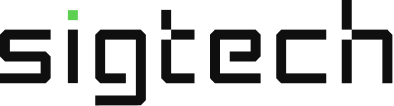
</div>

# Bonds Demo

- Environment
- Objects
- Building Blocks
- Example Strategies

___

## Environment

In [1]:
import datetime as dtm
import pandas as pd
import numpy as np

In [2]:
import sigtech.framework as sig

env = sig.init()

SigTech environment successfully initialized


___

## Objects

There are three fundamental objects in the platform:
- **Tradable instruments**: instruments, tradable on the financial markets,
- (Tradable) **Strategies**: a set of rules and logic to buy or sell tradable instruments over time,
- **Non-tradable data**: objects that are used for signalling purposes or research like macro-economic data.
<br>

<div align='center'>
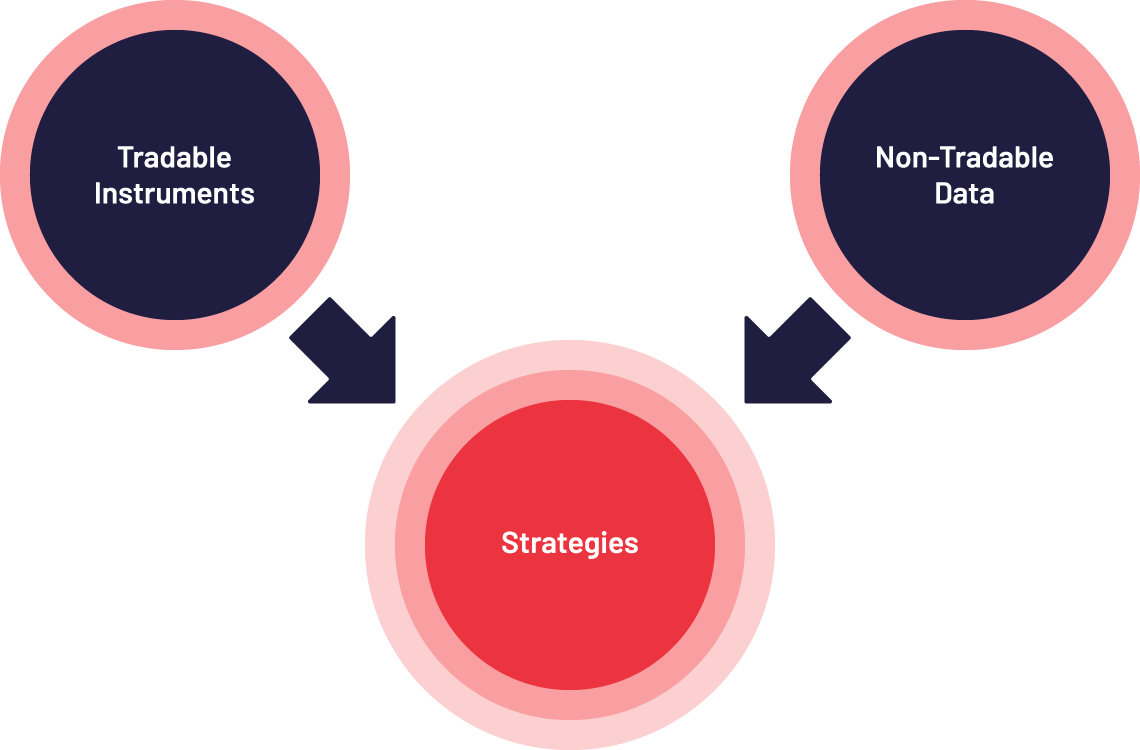
</div>


In [3]:
bond = sig.obj.get("US 0.25 2025/10/31 GOVT")
bond

US 0.25 2025/10/31 GOVT <class 'sigtech.framework.instruments.bonds.GovernmentBond'>[140440713393872]

In [4]:
bond?

Type:           GovernmentBond
String form:    US 0.25 2025/10/31 GOVT <class 'sigtech.framework.instruments.bonds.GovernmentBond'>[140440713393872]
File:           /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/instruments/bonds.py
Docstring:     
Government Bond - represents GOVT bond instrument.

Example object retrieval using different symbologies:

.. code-block:: python

    import sigtech.framework as sig

    sig.init()

    sig.obj.get('US 2.625 2029/02/15 GOVT')
    sig.obj.get('US 2.625 2029/02/15 GOVT', symbology=Symbology.SIG)
    sig.obj.get('US9128286B18', symbology=Symbology.ISIN)
    sig.obj.get('9128286B1', symbology=Symbology.CUSIP)
Init docstring: Method generated by attrs for class GovernmentBond.

In [5]:
bond.isin

'US91282CAT80'

In [6]:
sig.obj.get("US91282CAT80", symbology=sig.common.Symbology.ISIN)

US 0.25 2025/10/31 GOVT <class 'sigtech.framework.instruments.bonds.GovernmentBond'>[140440713393872]

In [7]:
bond.info()

{'Name': 'US 0.25 2025/10/31 GOVT',
 'ExchangeCode': 'OTCNYC EXCHANGE GROUP',
 'Type': 'GovernmentBond',
 'TypeShort': 'GB',
 'Ticker': 'US 0.25 2025/10/31',
 'Currency': 'USD',
 'ExpiryDatetime': datetime.datetime(2025, 10, 31, 19, 0, tzinfo=<UTC>),
 'BBGTicker': 'US91282CAT80',
 'ProductType': 'Government Bond',
 'SizeType': 'Notional',
 'GroupName': 'US GOVT BOND GROUP'}

In [8]:
bond.data_dict()

{'_product_type': 'Government Bond',
 'instrument_id': None,
 '_data_source_all': [],
 '_available_data_points': ['INTRADAY_1MIN',
  'INTRADAY_5MIN',
  'INTRADAY_10MIN',
  'INTRADAY_1HOUR',
  'EOD'],
 '_default_data_point': 'EOD',
 'price_factor': 1.0,
 'use_price_factor': True,
 'intraday_times': [],
 'intraday_tz_str': 'UTC',
 'currency': 'USD',
 'ticker': 'US 0.25 2025/10/31',
 'db_ticker': None,
 'db_sector': None,
 '_exchange_code': 'OTCNYC EXCHANGE GROUP',
 'activity_fields': ['Volume'],
 'group_name': 'US GOVT BOND GROUP',
 'coupon': 0.25,
 'coupon_type': 'FIXED',
 'coupon_frequency': 'SEMI_ANNUAL',
 'issue_date': datetime.date(2020, 11, 2),
 'issuer': 'United States Treasury Notes',
 'maturity_date': datetime.date(2025, 10, 31),
 'first_coupon_date': datetime.date(2021, 4, 30),
 'int_acc_date': datetime.date(2020, 10, 31),
 'redemption_amount': 100.0,
 'day_count': 'ACT/ACT',
 'isin': 'US91282CAT80',
 'description': "0.25% NTS 31/10/2025 USD 'AF-2025'",
 'days_to_settle': 1,
 '

In [9]:
bond.history_fields

['AskPrice',
 'BidPrice',
 'LastPrice',
 'data_point',
 'HighPrice',
 'LowPrice',
 'MidPrice',
 'OpenPrice',
 'open_interest',
 'Volume',
 'DirtyAskPrice',
 'DirtyBidPrice',
 'DirtyLastPrice',
 'ModDuration',
 'DV01',
 'YTM']

In [10]:
bond.history().tail()

2023-03-17    91.422857
2023-03-20    91.259485
2023-03-21    90.773847
2023-03-22    91.255007
2023-03-23    91.255007
Name: (DirtyLastPrice, EOD, US 0.25 2025/10/31 GOVT), dtype: float64

In [11]:
bond.intraday_history().tail()

trading_datetime
2023-03-22 20:59:00+00:00    91.240234
2023-03-22 21:01:00+00:00    91.222656
2023-03-22 21:02:00+00:00    91.224609
2023-03-22 21:06:00+00:00    91.203125
2023-03-22 21:11:00+00:00    91.203125
Name: (LastPrice, US 0.25 2025/10/31 GOVT), dtype: float64

<AxesSubplot:>

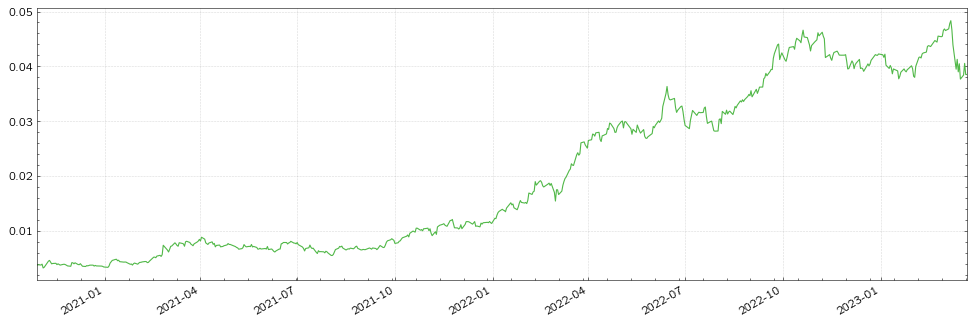

In [12]:
bond.history("YTM").plot()

In [13]:
bond.cashflows(dtm.date.today())

array([[datetime.date(2023, 5, 1), 0.12499999999999734, 0.0],
       [datetime.date(2023, 10, 31), 0.12499999999999734, 0.0],
       [datetime.date(2024, 4, 30), 0.12499999999999734, 0.0],
       [datetime.date(2024, 10, 31), 0.12499999999999734, 0.0],
       [datetime.date(2025, 4, 30), 0.12499999999999734, 0.0],
       [datetime.date(2025, 10, 31), 0.12499999999999734, 100.0]],
      dtype=object)

In [14]:
bond.z_spreads()

2020-10-29    15.431064
2020-10-30    14.665069
2020-11-02    15.495777
2020-11-03    14.853766
2020-11-04    14.194649
                ...    
2023-03-17    12.880610
2023-03-20     8.084809
2023-03-21     8.233639
2023-03-22    10.225814
2023-03-23    10.517803
Length: 601, dtype: float64

In [15]:
bond.asw_spreads()

2020-10-29    -6.262482
2020-10-30    -6.742617
2020-11-02    -5.681257
2020-11-03    -6.049220
2020-11-04    -6.966424
                ...    
2023-03-17   -17.675249
2023-03-20   -22.107292
2023-03-21   -18.076585
2023-03-22   -16.281502
2023-03-23   -16.248524
Length: 601, dtype: float64

In [54]:
bond.carry_roll_down(
    d=dtm.date.today(),
    dates=[
        dtm.datetime(2023, 5, 5),
        dtm.datetime(2024, 6, 6),
        dtm.datetime(2025, 7, 7),
    ],
)

,carry,roll_down,carry/pv01,roll_down/pv01,yield_carry,yield_roll_down
2023-05-05,0.125,0.223604,0.000539,0.000963,0.001937,-0.000239
2024-06-06,0.375,3.118886,0.001616,0.013439,0.033660,-0.002355
2025-07-07,0.625,7.299482,0.002693,0.031452,0.304015,-0.004482


In [17]:
bond.get_bond_repo()

US 0.25 2025/10/31 REPO GOVT <class 'sigtech.framework.instruments.bonds.GovernmentBondRepo'>[140440112474960]

In [18]:
bond.get_bond_swap()

US 0.25 2025/10/31 SWAP GOVT <class 'sigtech.framework.instruments.bonds.GovernmentBondSwap'>[140440101950944]

In [19]:
bond.matching_swap()

USD LIBOR SEMI_ANNUAL3M 0.0025 2020-11-02 2020-11-04X2025-10-31 FLT_SPRD -0.056813 FIX_DC ACT/ACT IRS <class 'sigtech.framework.instruments.ir_otc.InterestRateSwap'>[140440666733200]

___

## Building Blocks

Within the SigTech platform, the user has the ability to use **Building Blocks**, a set of pre-built methods designed to speed up the process of creating basic strategies.

`RollingBondStrategy` is the building block that rolls bonds according to a given run type. It invests in the underlying bonds and reinvests coupons.
Some import keyword arguments include:
* Country
* Tenor 
* Run Type

In [20]:
sig.RollingBondStrategy?

Init signature:
sig.RollingBondStrategy(
    *,
    cache: Optional[bool] = True,
    identifier: Optional[sigtech.framework.infra.data_adapter.identifier.Identifier] = None,
    env: Optional[sigtech.framework.config.config.ConfiguredEnvironment] = NOTHING,
    product_type: Optional[str] = None,
    instrument_id: Optional[int] = None,
    data_source_all: Optional[list] = NOTHING,
    available_data_points: Optional[list] = NOTHING,
    default_data_point: Optional[sigtech.framework.infra.data_adapter.common.DataPoint] = 'EOD',
    price_factor: float = 1.0,
    use_price_factor: Optional[bool] = True,
    intraday_times: Optional[list] = NOTHING,
    intraday_tz_str: Optional[str] = 'UTC',
    ticker: Optional[str] = None,
    db_ticker: Optional[str] = None,
    db_sector: Optional[str] = None,
    initial_cash: Optional[float] = 1000.0,
    strategy_sizing_quantity: Optional[float] = None,
    start_date: Optional[datetime.date] = None,
    end_date: Optional[datetime.date] = dat

In [21]:
rolling_10y = sig.RollingBondStrategy(
    start_date=dtm.date(2013, 1, 1),
    country="US",
    tenor="10Y",
    run_type="ON_THE_RUN",
    ticker="ROLLING OTR 10Y US BOND",
)

<AxesSubplot:>

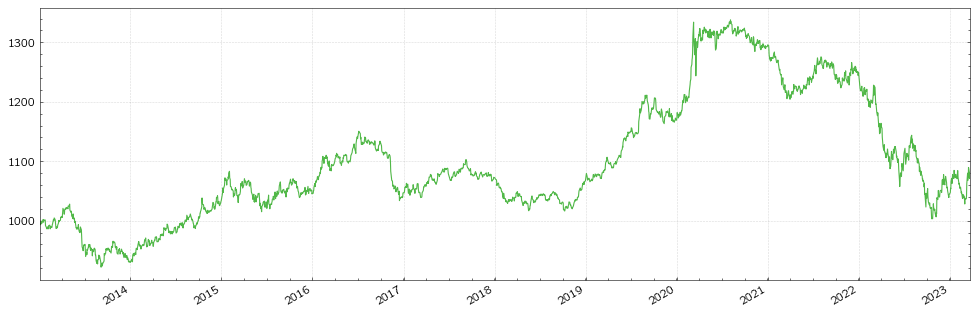

In [22]:
rolling_10y.history().plot()

In [23]:
rolling_10y.plot.timeline()

In [24]:
rolling_10y.plot.portfolio_table("TOP_ORDER_PTS", start_dt=dtm.date(2022, 9, 30), flatten=True)

In [25]:
rolling_10y.yield_series().tail()

2023-03-17    0.032824
2023-03-20    0.033664
2023-03-21    0.034909
2023-03-22    0.033880
2023-03-23    0.033880
dtype: float64

In [26]:
rolling_10y.ann01_series().tail()

2023-03-17    8.299913
2023-03-20    8.287556
2023-03-21    8.270527
2023-03-22    8.279648
2023-03-23    8.279648
dtype: float64

___

## Example Strategy: 10y2y Spread Signal

In [27]:
rolling_2y = sig.RollingBondStrategy(
    start_date=dtm.date(2013, 1, 1),
    country="US",
    tenor="2Y",
    run_type="ON_THE_RUN",
    ticker="ROLLING OTR 2Y US BOND",
)

In [28]:
basket = sig.BasketStrategy(
    constituent_names=[rolling_2y.name, rolling_10y.name],
    weights=[1, -1],
    rebalance_frequency="3M",
    ticker="LONG 2Y SHORT 10Y",
)

<AxesSubplot:>

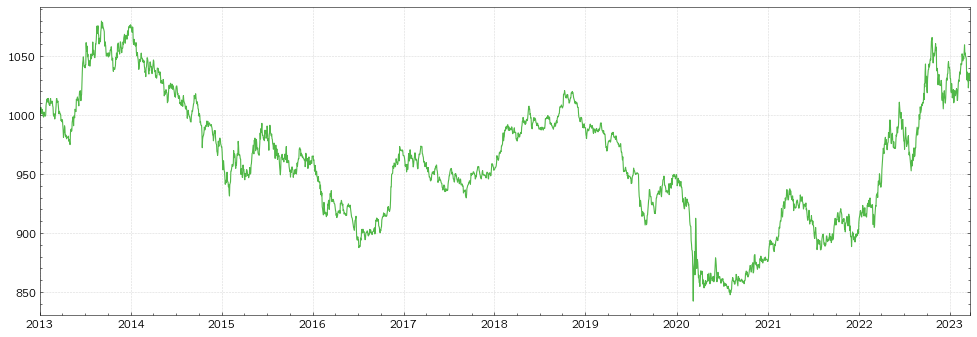

In [29]:
basket.history().plot()

In [30]:
basket.plot.tree()

,Strategy
,Position
,Cash
,Instrument Order
,Grouped Order
,Strategy Order
,FX Spot Order


In [31]:
yield_spread = rolling_10y.yield_series(adjusted=False) - rolling_2y.yield_series(adjusted=False)

<AxesSubplot:>

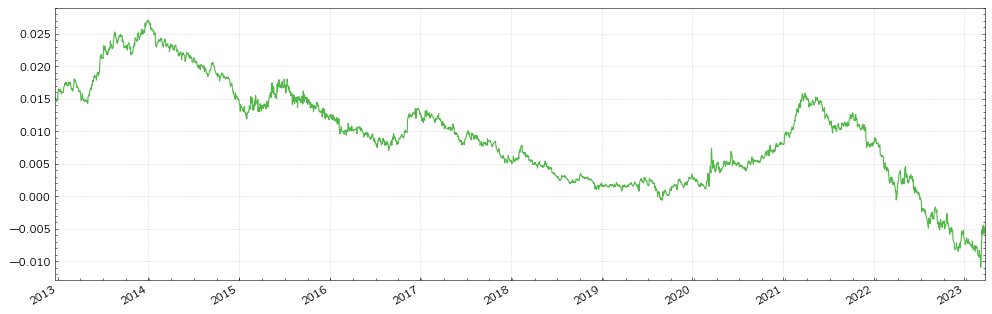

In [32]:
yield_spread.plot()

In [33]:
signal_df = np.sign(yield_spread.pct_change(21).dropna())
signal_df.name = basket.name
signal_df = signal_df.to_frame()
signal_df

,LONG 2Y SHORT 10Y STRATEGY
2013-01-22,1.0
2013-01-23,1.0
2013-01-24,1.0
2013-01-25,1.0
2013-01-28,1.0
...,...
2023-03-17,-1.0
2023-03-20,-1.0
2023-03-21,-1.0
2023-03-22,-1.0


In [34]:
yield_spread_strategy = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 22),
    signal_name=sig.signal_library.from_ts(signal_df).name,
    threshold_function=sig.signal_library.threshold_fns.signal_change_threshold_function,
    ticker="10Y2Y YIELD SPREAD",
)

In [35]:
yield_spread_strategy.plot.performance()

LayoutWidget(Layout(load_visualisation(7fbaa9b75860, self=<sigtech.framework.experimental.ui.strategy_performa…

___

## Example Strategy: Bond Auction Intraday Strategy

In [36]:
ust_cal = sig.obj.get("US_GOVT_AUC_10Y CALENDAR")

In [37]:
ust_cal.calendar_days[-10:]

[datetime.date(2023, 7, 12),
 datetime.date(2023, 8, 9),
 datetime.date(2023, 9, 13),
 datetime.date(2023, 10, 11),
 datetime.date(2023, 11, 8),
 datetime.date(2023, 12, 13),
 datetime.date(2024, 1, 10),
 datetime.date(2024, 2, 7),
 datetime.date(2024, 3, 13),
 datetime.date(2024, 4, 10)]

In [38]:
from sigtech.framework.default_strategy_objects.rolling_futures import ty_comdty_front

In [39]:
ty_comdty_front??

Signature: ty_comdty_front(use_cache: bool = True)
Source:   
@register_default_strategy(test_on_nightly_only=True)
def ty_comdty_front(use_cache: bool = USE_STRATEGY_SERVICE):
    """
    Define a rolling future strategy in USD with contract code ``'TY'`` (commodity), rolling rule ``'front'``
    and front offset ``'-3:-2'``.
    """
    return _create_rolling_future(
        {'currency': 'USD', 'start_date': datetime.date(2010, 1, 4), 'contract_code': 'TY', 'contract_sector': 'COMDTY',
         'rolling_rule': 'front', 'ticker': 'USD TY COMDTY Long front RF', 'front_offset': '-3:-2'},
        use_cache=use_cache)
File:      /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/default_strategy_objects/rolling_futures.py
Type:      function

In [40]:
entry_df = pd.DataFrame(
    {ty_comdty_front().name: 1, rolling_10y.name: -1},
    index=[dtm.datetime.combine(x, dtm.time(9, 0)) for x in ust_cal.calendar_days],
)
exit_df = pd.DataFrame(
    {ty_comdty_front().name: 0, rolling_10y.name: 0},
    index=[dtm.datetime.combine(x, dtm.time(18, 0)) for x in ust_cal.calendar_days],
)

In [41]:
signal_df = pd.concat([entry_df, exit_df]).sort_index()
signal_df

,USD TY COMDTY LONG FRONT RF STRATEGY,ROLLING OTR 10Y US BOND STRATEGY
2000-02-09 09:00:00,1,-1
2000-02-09 18:00:00,0,0
2000-05-10 09:00:00,1,-1
2000-05-10 18:00:00,0,0
2000-08-09 09:00:00,1,-1
...,...,...
2024-02-07 18:00:00,0,0
2024-03-13 09:00:00,1,-1
2024-03-13 18:00:00,0,0
2024-04-10 09:00:00,1,-1


In [42]:
intraday_strategy = sig.IntradaySignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    signal_name=sig.signal_library.from_ts(signal_df).name,
    ticker="BOND AUCTION INTRADAY",
    total_return=False,
)

In [43]:
intraday_strategy.plot.performance()

2023-03-23 11:49:48,438 [3271] [sigtech.framework.instruments.base] WARNING: For instrument US 1.625 2022/11/15 GOVT the data point INTRADAY_5MIN seems to be missing data (date range 2013-01-02 18:05:00+00:00, 2013-01-09 18:05:00+00:00)
2023-03-23 11:49:48,611 [3271] [sigtech.framework.instruments.base] WARNING: For instrument US 1.625 2022/11/15 GOVT the data point INTRADAY_1MIN seems to be missing data (date range 2013-01-02 18:05:00+00:00, 2013-01-09 18:05:00+00:00)
2023-03-23 11:49:49,115 [3271] [sigtech.framework.instruments.base] WARNING: For instrument US 2 2023/02/15 GOVT the data point INTRADAY_5MIN seems to be missing data (date range 2013-03-06 18:05:00+00:00, 2013-03-13 18:05:00+00:00)
2023-03-23 11:49:49,260 [3271] [sigtech.framework.instruments.base] WARNING: For instrument US 2 2023/02/15 GOVT the data point INTRADAY_1MIN seems to be missing data (date range 2013-03-06 18:05:00+00:00, 2013-03-13 18:05:00+00:00)
2023-03-23 11:49:49,839 [3271] [sigtech.framework.instrument

LayoutWidget(Layout(load_visualisation(7fba9fbff3b0, self=<sigtech.framework.experimental.ui.strategy_performa…

In [44]:
intraday_strategy.plot.timeline()

In [45]:
intraday_strategy.inspect.bottom_trades_df()

,instrument_name,display_name,trade_size,payment_currency,transaction_type,valuation,trade_price
dt,,,,,,,
2013-01-09 09:05:00+00:00,TYH13 COMDTY,TYH13 COMDTY,7.582408,USD,outright,131.859375,131.859375
2013-01-09 09:05:00+00:00,TYH13 COMDTY VALUATION OFFSET,TYH13 COMDTY VALUATION OFFSET,-999.811645,USD,outright,1.000000,1.000000
2013-01-09 09:05:00+00:00,US 1.625 2022/11/15 GOVT,US 1.625 2022/11/15 GOVT,-10.112425,USD,outright,98.059392,98.059392
2013-01-09 09:05:00+00:00,USD CASH,USD CASH,991.618278,USD,outright,1.000000,1.000000
2013-01-09 18:05:00+00:00,TYH13 COMDTY,TYH13 COMDTY,-7.582408,USD,outright,131.953125,131.953125
...,...,...,...,...,...,...,...
2023-03-08 09:05:00+00:00,USD CASH,USD CASH,1408.769629,USD,outright,1.000000,1.000000
2023-03-08 18:05:00+00:00,TYM23 COMDTY,TYM23 COMDTY,-12.677291,USD,outright,110.890625,110.890625
2023-03-08 18:05:00+00:00,TYM23 COMDTY VALUATION OFFSET,TYM23 COMDTY VALUATION OFFSET,1406.585094,USD,outright,1.000000,1.000000


___

## Optimization

In [46]:
combined_strategy_df = pd.DataFrame(
    {
        yield_spread_strategy.name: yield_spread_strategy.history(),
        intraday_strategy.name: intraday_strategy.history(),
    }
)
returns_df = combined_strategy_df.pct_change().dropna()

In [47]:
sig.Optimizer?

Init signature:
sig.Optimizer(
    factor_exposures: Optional[sigtech.framework.analytics.optimization.factor_exposure.FactorExposures] = None,
    optimization_problem: Optional[sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem] = None,
    factor_exposure_kwargs: Optional[dict] = None,
    cvx_kwargs: Optional[dict] = None,
    scipy_kwargs: Optional[dict] = None,
)
Docstring:     
A class implementing an optimisation task.

To run an optimisation problem, a ``OptimizationProblem`` object needs to be provided.

If fit requires Factors then the ``FactorExposures`` containing the data must also be passed and the weights are     found with ``Optimizer.calculate_optimized_weights``.
Otherwise, if the optimization does not require knowledge of factors, ``FactorExposures=None`` is valid but     ``calculate_optimized_weights_with_fit`` must be used.

.. seealso:: `sigtech.framework.analytics.optimization.optimization_problem.OptimizationProblem`

An example o

In [48]:
opt = sig.PortfolioOptimizer()
opt.prefer_mean_variance().calculate_weights(returns_df)

10Y2Y YIELD SPREAD STRATEGY        6.756751
BOND AUCTION INTRADAY STRATEGY    81.296238
dtype: float64

In [49]:
opt.require_equal_risk_contribution().require_fully_invested().calculate_weights(returns_df)

2023-03-23 11:50:30,642 [3271] [sigtech.framework.internal.utils.deprecation] WARNING: Call to deprecated function 'require_equal_risk_contribution' from /opt/conda/envs/sig-env/lib/python3.9/site-packages/sigtech/framework/analytics/optimization/portfolio_optimizer.py:902. Method require_equal_risk_contribution() is deprecated since it adds an objective contribution. Please use prefer_equal_risk_contribution() instead. 'require_equal_risk_contribution' will be removed in framework v9.


10Y2Y YIELD SPREAD STRATEGY      -0.310422
BOND AUCTION INTRADAY STRATEGY    1.310422
dtype: float64

In [50]:
po = sig.PortfolioOptimizer().prefer_inverse_vol_weighting().require_long_only().require_fully_invested()

optimized_strategy_inverse_vol = sig.SignalStrategy(
    currency="USD",
    start_date=dtm.date(2013, 1, 1),
    rebalance_frequency="EOM",
    signal_name=sig.signal_library.from_ts(combined_strategy_df).name,
    allocation_function=sig.signal_library.allocation.optimized_allocations,
    allocation_kwargs={
        "periods": 252,
        "optimization_frequency": "EOM",
        **po.signal_strategy_allocation_kwargs(),
    },
    ticker="Inverse Volatility Basket",
)

Optimizations:   0%|          | 0/122 [00:00<?, ?it/s]

<AxesSubplot:>

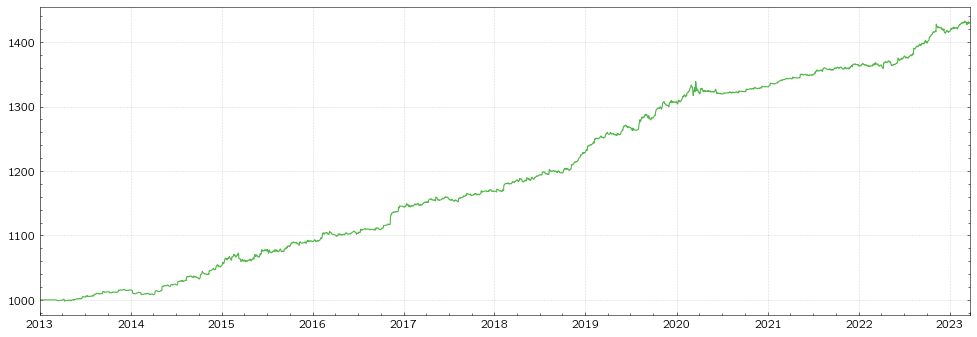

In [51]:
optimized_strategy_inverse_vol.history().plot()

In [56]:
optimized_strategy_inverse_vol.plot.portfolio_table()

___

## Performance and Analytics

,10Y2Y YIELD SPREAD STRATEGY,BOND AUCTION INTRADAY STRATEGY,INVERSE VOLATILITY BASKET STRATEGY
Annualised Excess Return,4.64%,3.41%,3.56%
Annualised Standard Deviation,6.00%,1.42%,1.58%
Annualised Sharpe Ratio (vs Cash),0.760,2.292,2.151
Annualised Sortino Ratio (vs Cash),1.289,8.678,4.582
Max Drawdown,-9.97%,-0.90%,-1.44%
Kurtosis,5.435,48.590,15.629
Skewness,0.159,5.877,1.991
Mean Positive Return,0.27%,0.38%,0.06%
Mean Negative Return,-0.27%,-0.21%,-0.05%
Proportion Positive Returns,53.49%,3.86%,56.08%


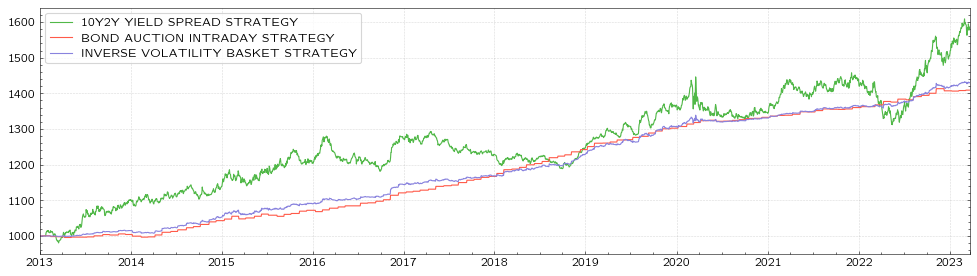

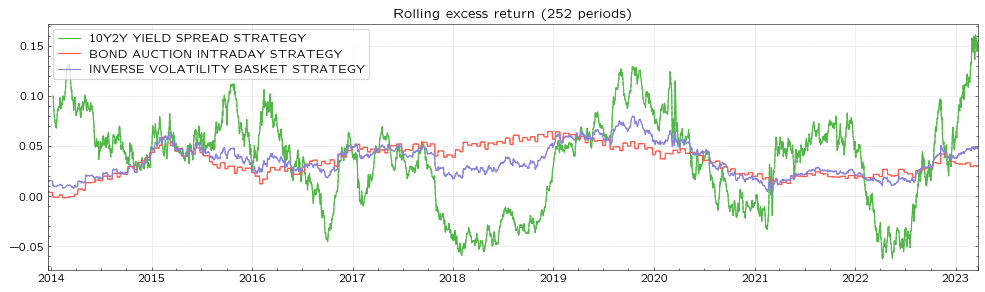

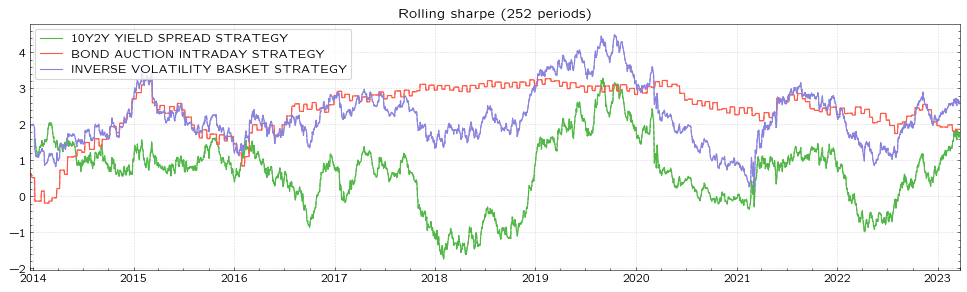

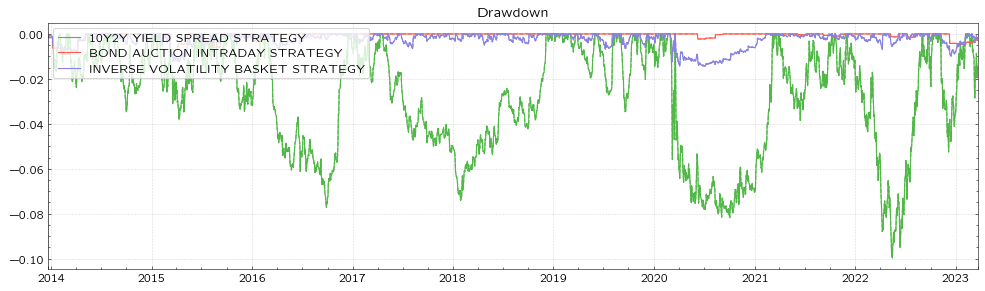

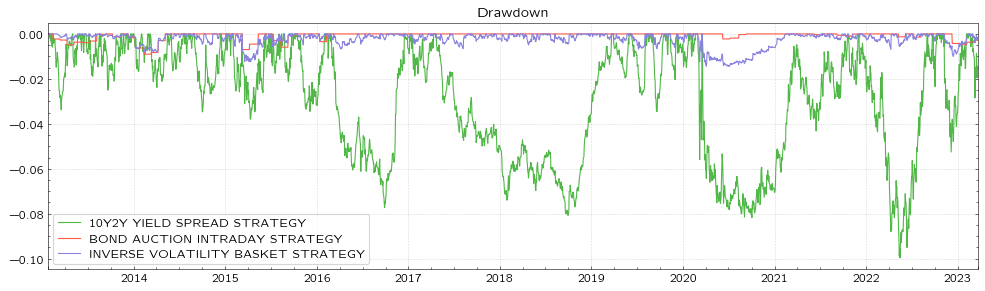

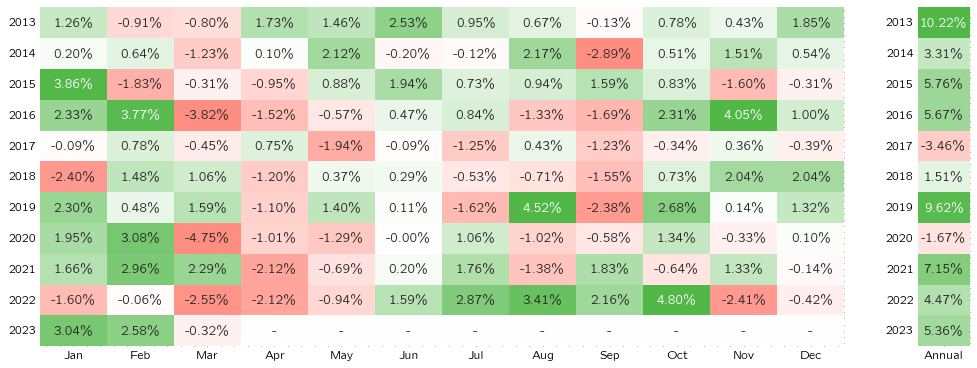

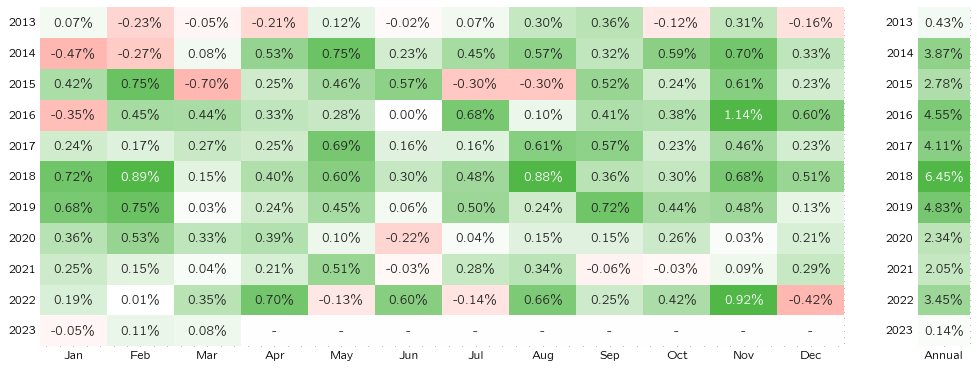

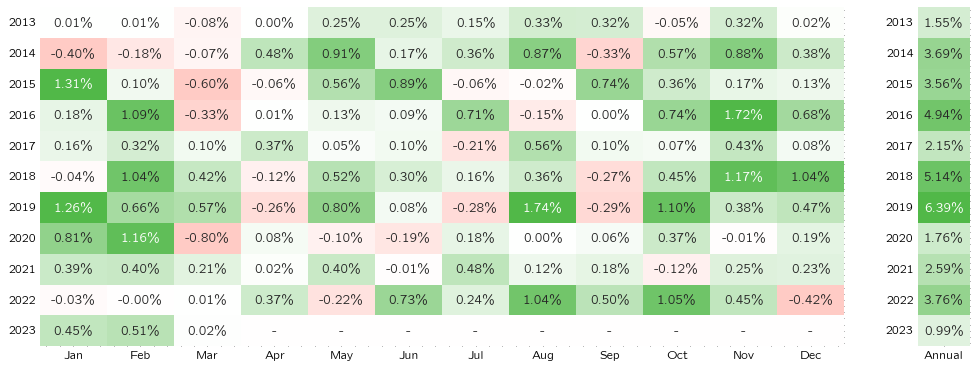

In [53]:
sig.PerformanceReport([yield_spread_strategy, intraday_strategy, optimized_strategy_inverse_vol]).report()